# 03 — QAOA single run + landscape

One QAOA configuration end-to-end on the canonical 16-equity universe
(Mag7 + quantum + quantum_big + anti) at `K=4, p=3`: the multi-start
training spread, the top-5 most likely bitstrings, the probability mass
on budget-feasible (K=4) states, and a $p=1$ $E(\gamma,\beta)$ landscape
heatmap for context.

Defaults: 10 random `(gamma, beta)` inits, COBYLA `maxiter=200`,
`rhobeg=0.1`. Single-seed QAOA is not meaningful — the landscape is
non-convex enough that the multi-start is mandatory.

> **Runtime:** ~4–5 min on Colab CPU (one p=3 solve ~2.5 min + one p=1 solve
> ~30 s + landscape scan ~1 min). Saves `plots/qaoa/single_run_universe_p3.pdf`
> and `plots/analysis/universe_p1_landscape.pdf`.

In [1]:
# === Bootstrap (Colab + local) ===
import os, urllib.request as _u
exec((open('../scripts/bootstrap.py') if os.path.exists('../scripts/bootstrap.py') else _u.urlopen('https://raw.githubusercontent.com/egil10/fys5419/main/project2/code/scripts/bootstrap.py')).read())

# === Project imports ===
import numpy as np
import matplotlib.pyplot as plt

from scripts.data      import load_universe
from scripts.portfolio import PortfolioProblem, DEFAULTS
from scripts.classical import brute_force
from scripts.qaoa      import solve, decode_top_k
from scripts.metrics   import prob_optimal, prob_feasible
from scripts.plotting  import apply_style, PALETTE, title, fig_path
apply_style()

> /usr/bin/python3 -m pip install -q numpy pandas scipy matplotlib yfinance pyarrow
[colab.setup] env=Colab
[colab.setup] cwd  = /content/fys5419/project2/code/notebooks
[colab.setup] path = /content/fys5419/project2/code  (added to sys.path)


In [2]:
# === Canonical instance: n=16, K=4, p=3 ===
P = 3

r  = load_universe()
pf = PortfolioProblem(r.mu, r.Sigma,
                      lam=DEFAULTS['lam'], A=DEFAULTS['A'],
                      K=DEFAULTS['K_AT_16'], tickers=r.tickers)

bf  = brute_force(pf)
res = solve(pf, p=P, n_restarts=10, seed=42, verbose=False)

print(f'brute force:  x={bf.bitstring}  C={bf.cost:.6f}')
print(f'              picks: {bf.tickers(pf)}')
print(f'QAOA p={P}:     E={res["energy"]:.6f}  ratio={res["ratio"]:.4f}')
print(f'P(optimum)  = {prob_optimal(res["probs"], bf.x):.4f}')
print(f'P(feasible) = {prob_feasible(res["probs"], pf.n, pf.K):.4f}')

brute force:  x=0010000010010001  C=-0.001404
              picks: ['GOOGL', 'IBM', 'NVDA', 'JPM']
QAOA p=3:     E=3.997202  ratio=0.9446
P(optimum)  = 0.0002
P(feasible) = 0.3113


### Top-5 bitstrings

In [ ]:
import pandas as pd
from scripts.metrics import sharpe

# Top-5 with portfolio Sharpe added so the financial story is concrete:
# the all-ones state has Sharpe 0.073 vs the brute-force optimum's 0.136 —
# even when QAOA picks something feasible, infeasible all-asset bets are
# strictly worse for the investor, not just for the QUBO.
top = decode_top_k(res['probs'], pf, k=5)
for row in top:
    row['sharpe'] = sharpe(row['x'], pf.mu, pf.Sigma)
pd.DataFrame(top)[['bitstring', 'prob', 'cost', 'budget', 'sharpe']]

### Figures — training restarts + probability histogram

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


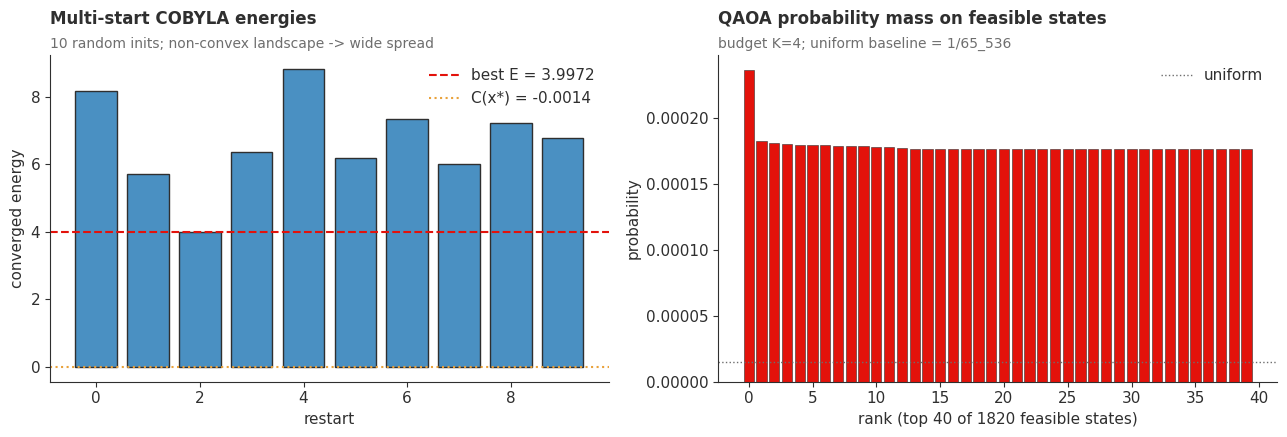

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Multi-seed restart energies — shows the landscape is non-convex
energies = [h['fun'] for h in res['history']]
axes[0].bar(range(len(energies)), energies,
            color=PALETTE['blue_muted'], edgecolor=PALETTE['charcoal'])
axes[0].axhline(res['energy'], color=PALETTE['red'], ls='--', lw=1.5,
                label=f'best E = {res["energy"]:.4f}')
axes[0].axhline(bf.cost, color=PALETTE['ochre'], ls=':', lw=1.5,
                label=f'C(x*) = {bf.cost:.4f}')
axes[0].set_xlabel('restart'); axes[0].set_ylabel('converged energy')
title(axes[0], 'Multi-start COBYLA energies',
      f'{len(energies)} random inits; non-convex landscape -> wide spread')
axes[0].legend()
axes[0].grid(False)

# Probability over budget-feasible bitstrings only (n=16 -> 65k states is too many to plot)
probs = res['probs']
n_states = len(probs)
feas_mask = np.array([bin(k).count('1') == pf.K for k in range(n_states)])
feas_probs = probs[feas_mask]
order = np.argsort(-feas_probs)
top = min(40, len(feas_probs))
axes[1].bar(range(top), feas_probs[order][:top],
            color=PALETTE['red'], edgecolor=PALETTE['charcoal'], linewidth=0.4)
axes[1].set_xlabel(f'rank (top {top} of {len(feas_probs)} feasible states)')
axes[1].set_ylabel('probability')
title(axes[1], 'QAOA probability mass on feasible states',
      f'budget K={pf.K}; uniform baseline = 1/{n_states:_}')
axes[1].axhline(1.0/n_states, color=PALETTE['grey'], ls=':', lw=1, label='uniform')
axes[1].legend()
axes[1].grid(False)

plt.tight_layout()
fig.savefig(fig_path('qaoa', f'single_run_universe_p{P}'), bbox_inches='tight')
plt.show()

### Landscape — $E(\gamma, \beta)$ at $p=1$

Two-angle energy surface for the same canonical instance. Cheap diagnostic:
shows whether the variational landscape has a single broad basin or several
near-degenerate minima — which informs whether multi-start COBYLA is enough
or you'd want warm-starts from lower $p$. The red star marks the best
$(\gamma, \beta)$ found by `solve(p=1, n_restarts=10)`.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
saved -> universe_p1_landscape.pdf


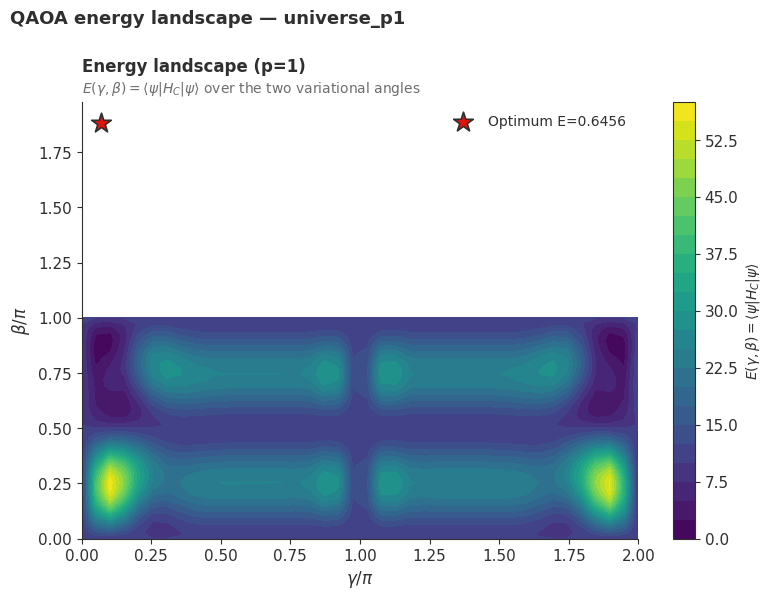

In [5]:
from scripts.analysis import Landscape

# p=1 has just two angles, so a 40x40 grid is 1600 H_C evaluations -- a few
# seconds on n=16. For the overlay we need a p=1 solve specifically (the
# one above used p=3), so call solve again briefly.
from scripts.qaoa import solve as _solve
res_p1 = _solve(pf, p=1, n_restarts=10, seed=42)

land = Landscape(pf, n_pts=40).scan()
land.plot(result_p1=res_p1, save=True, name='universe_p1')

### Cost spectrum — why the scaled ratio looks so good

Histogram of $C(x)$ over all $2^{16} \approx 65{,}000$ bitstrings,
colour-coded by feasibility. The feasible bitstrings (Hamming weight = K = 4)
live in a narrow band near $C \approx 0$, while the all-ones state sits
way out at $C \approx 72$. That spread is what makes the scaled
approximation ratio of ~0.94 "look good" — most of the mass is in the
infeasible tail that any reasonable QAOA stays away from. The plot makes
the verbal argument visual.

In [ ]:
from scripts.qaoa import make_hamiltonians

# Cost values for every basis state (already used inside `solve`).
_, _, _, _, _, HC = make_hamiltonians(pf)
all_costs = HC.real

# Hamming weight of each basis index.
n = pf.n
weights = np.array([bin(k).count('1') for k in range(1 << n)])
feas_mask = (weights == pf.K)

# Three landmark costs to annotate:
c_opt   = bf.cost                                  # brute-force optimum
c_qaoa  = float(res['energy'])                     # QAOA expectation
c_ones  = float(all_costs[(1 << n) - 1])           # all-ones basis state
c_zero  = float(all_costs[0])                      # all-zeros basis state

fig, ax = plt.subplots(figsize=(11, 4.5))
bins = np.linspace(all_costs.min(), all_costs.max(), 80)
ax.hist(all_costs[~feas_mask], bins=bins, color=PALETTE['grey'],
        alpha=0.55, label=f'infeasible ($|x|\\neq{pf.K}$)',
        edgecolor=PALETTE['charcoal'], linewidth=0.2)
ax.hist(all_costs[feas_mask],  bins=bins, color=PALETTE['red'],
        alpha=0.85, label=f'feasible ($|x|={pf.K}$)',
        edgecolor=PALETTE['charcoal'], linewidth=0.2)

for c, lab, ls in [(c_opt,  f'$C(x^*) = {c_opt:+.3f}$',     '-'),
                   (c_qaoa, f'QAOA $E={c_qaoa:+.3f}$',      '--'),
                   (c_ones, f'all-ones $C={c_ones:+.2f}$',  ':')]:
    ax.axvline(c, color=PALETTE['charcoal'], ls=ls, lw=1.3, label=lab)

ax.set_yscale('log')
ax.set_xlabel(r'portfolio cost $C(x)$')
ax.set_ylabel('count (log)')
title(ax, f'Cost spectrum over all $2^{{{n}}}$ bitstrings',
      'feasible mass sits near zero; the all-ones state inflates the scaled-ratio denominator')
ax.legend(fontsize=8, loc='upper right')
ax.grid(False)

plt.tight_layout()
fig.savefig(fig_path('analysis', 'cost_spectrum'), bbox_inches='tight')
plt.show()

### Probability stratified by Hamming weight

A single number ($P(\text{feasible}) = 0.31$ at $p=3$) hides the
distribution. Plot $P(|x| = k)$ for $k = 0, \dots, 16$ alongside the
uniform-mixer baseline $\binom{n}{k} / 2^n$. If QAOA had concentrated
mass near $k = K = 4$, the red bars would tower over the dashed line at
that bin; if QAOA is essentially mass-preserving relative to uniform,
the bars track the dashed line. Either reading is informative.

In [ ]:
from math import comb

# Group QAOA probability mass by Hamming weight.
n = pf.n
weights = np.array([bin(k).count('1') for k in range(1 << n)])
mass = np.zeros(n + 1)
for k in range(n + 1):
    mass[k] = res['probs'][weights == k].sum()

# Uniform-mixer reference: binomial baseline binom(n,k)/2^n.
uniform = np.array([comb(n, k) for k in range(n + 1)], dtype=float) / (1 << n)

fig, ax = plt.subplots(figsize=(11, 4.5))
xs = np.arange(n + 1)
bars = ax.bar(xs, mass, color=PALETTE['red'], alpha=0.85,
              edgecolor=PALETTE['charcoal'], linewidth=0.6,
              label=f'QAOA p={P}')
ax.plot(xs, uniform, 'o--', color=PALETTE['blue'], lw=1.6, ms=6,
        label=r'uniform mixer $\binom{n}{k}/2^n$')
# Mark the budget K.
ax.axvline(pf.K, color=PALETTE['charcoal'], ls=':', lw=1.2,
           label=f'budget K={pf.K}')
ax.set_xticks(xs)
ax.set_xlabel('Hamming weight |x|')
ax.set_ylabel('probability mass')
title(ax, 'QAOA probability mass by Hamming weight',
      'compare to the uniform baseline — QAOA mass-preserving means budget penalty is not biting')
ax.legend(fontsize=9)
ax.grid(False)

plt.tight_layout()
fig.savefig(fig_path('analysis', 'hamming_weight_mass'), bbox_inches='tight')
plt.show()

### Landscape with all restart endpoints

The default landscape plot only marks the *best* restart. Here we overlay
every restart's converged $(\gamma^\star_r, \beta^\star_r)$ on the same
$E(\gamma, \beta)$ contour at $p=1$, labelled by restart index. If the
red dots pile up in the same basin, the landscape has one dominant well
and 10 restarts is overkill; if they spread across multiple basins, the
multi-start protocol is doing real work.

In [ ]:
# Build the p=1 contour grid from the same Landscape object we already have.
GG, BB = np.meshgrid(land.gammas, land.betas, indexing='ij')

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(GG / np.pi, BB / np.pi, land.energy, levels=25, cmap='viridis')
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label(r'$E(\gamma, \beta)$', fontsize=10)

# Every restart's endpoint, labelled by index. Modulo the periodicity of
# beta so widely-scattered final betas don't fall off-axis.
for hist in res_p1['history']:
    g = float(hist['x'][0]) % (2 * np.pi)
    b = float(hist['x'][1]) % np.pi
    ax.scatter(g / np.pi, b / np.pi, c=PALETTE['red'], s=90,
               edgecolors=PALETTE['charcoal'], linewidth=0.8, zorder=4)
    ax.annotate(str(hist['restart']),
                (g / np.pi, b / np.pi), xytext=(4, 4),
                textcoords='offset points', fontsize=7,
                color=PALETTE['charcoal'])

# Best endpoint as a gold star.
g_best = float(res_p1['gammas'][0]) % (2 * np.pi)
b_best = float(res_p1['betas'][0])  % np.pi
ax.scatter(g_best / np.pi, b_best / np.pi, c=PALETTE['ochre'], s=260,
           marker='*', edgecolors=PALETTE['charcoal'], linewidth=1.2,
           zorder=6, label=f"best E = {res_p1['energy']:.4f}")

ax.set_xlabel(r'$\gamma / \pi$', fontsize=12)
ax.set_ylabel(r'$\beta / \pi$', fontsize=12)
title(ax, 'p=1 landscape with every COBYLA restart endpoint',
      'red dots = where each of the 10 random inits converged; star = best')
ax.legend(fontsize=9, loc='upper right')
ax.grid(False)

plt.tight_layout()
fig.savefig(fig_path('analysis', 'universe_p1_landscape_with_restarts'),
            bbox_inches='tight')
plt.show()